## Cell 1 — Setup (paths, device, config, loaders)

In [2]:
from pathlib import Path
import sys
import torch
from torch.utils.data import DataLoader

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name.lower() == "notebooks" else cwd
sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import Kits2DSegDataset
from src.transforms import TransformConfig, SegTransform
from src.models import UNet
from src.train_seg import TrainConfig, train_one_epoch, evaluate, save_checkpoint

DATA_ROOT = Path(r"F:\projects\hirdl\FedSSL_Paper\data_set\kits_2d_splitted")
assert DATA_ROOT.exists()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# transforms + datasets
tfm = SegTransform(TransformConfig(out_size=256, to_3ch=True, normalize_01=True))
train_ds = Kits2DSegDataset(DATA_ROOT, "train", transform=tfm)
val_ds   = Kits2DSegDataset(DATA_ROOT, "val", transform=tfm)

# Windows notebook tip: if you see worker issues, set num_workers=0
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2, pin_memory=(DEVICE.type=="cuda"))
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2, pin_memory=(DEVICE.type=="cuda"))

cfg = TrainConfig(epochs=10, lr=3e-4, dice_weight=0.5, use_amp=True)
print(cfg)

Device: cuda
TrainConfig(lr=0.0003, weight_decay=0.0001, epochs=10, dice_weight=0.5, tumor_class=2, use_amp=True)


## Cell 2 — Model, optimizer, AMP scaler

In [3]:
import torch.optim as optim

model = UNet(in_channels=3, num_classes=3, base_ch=32).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and DEVICE.type=="cuda"))
print("Params:", sum(p.numel() for p in model.parameters())/1e6, "M")

Params: 7.849667 M


C:\Users\user\AppData\Local\Temp\ipykernel_10156\216634712.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and DEVICE.type=="cuda"))


## Cell 3 — Train loop + save best checkpoint

In [7]:
import pandas as pd

best_dice = -1.0
history = []

ckpt_path = Path("outputs/checkpoints/unet_baseline_best.pt")

for epoch in range(1, cfg.epochs + 1):
    tr = train_one_epoch(model, train_loader, optimizer, DEVICE, cfg, scaler=scaler)
    va = evaluate(model, val_loader, DEVICE, cfg)

    row = {"epoch": epoch, **tr, **va}
    history.append(row)
    df = pd.DataFrame(history)

    print(f"Epoch {epoch:02d} | "
          f"train_loss={row['train_loss']:.4f} | "
          f"val_loss={row['val_loss']:.4f} | "
          f"tumor_dice={row['tumor_dice']:.4f} | tumor_iou={row['tumor_iou']:.4f}")

    if row["tumor_dice"] > best_dice:
        best_dice = row["tumor_dice"]
        save_checkpoint(model, optimizer, epoch, row, ckpt_path)
        print("  -> saved best:", ckpt_path)

df

Epoch 01 | train_loss=0.0776 | val_loss=0.2918 | tumor_dice=0.4999 | tumor_iou=0.4241
  -> saved best: outputs\checkpoints\unet_baseline_best.pt
Epoch 02 | train_loss=0.0744 | val_loss=0.2930 | tumor_dice=0.4870 | tumor_iou=0.4172
Epoch 03 | train_loss=0.0720 | val_loss=0.2896 | tumor_dice=0.4994 | tumor_iou=0.4239
Epoch 04 | train_loss=0.0669 | val_loss=0.2883 | tumor_dice=0.5105 | tumor_iou=0.4256
  -> saved best: outputs\checkpoints\unet_baseline_best.pt
Epoch 05 | train_loss=0.0649 | val_loss=0.2914 | tumor_dice=0.4986 | tumor_iou=0.4267
Epoch 06 | train_loss=0.0619 | val_loss=0.2787 | tumor_dice=0.5200 | tumor_iou=0.4456
  -> saved best: outputs\checkpoints\unet_baseline_best.pt
Epoch 07 | train_loss=0.0632 | val_loss=0.3251 | tumor_dice=0.4506 | tumor_iou=0.3769
Epoch 08 | train_loss=0.0561 | val_loss=0.3002 | tumor_dice=0.4792 | tumor_iou=0.4138
Epoch 09 | train_loss=0.0576 | val_loss=0.2864 | tumor_dice=0.5046 | tumor_iou=0.4316
Epoch 10 | train_loss=0.0541 | val_loss=0.2872 | 

,epoch,train_loss,val_loss,tumor_dice,tumor_iou
0,1,0.077572,0.291785,0.499950,0.424121
1,2,0.074408,0.292973,0.486963,0.417182
2,3,0.071975,0.289590,0.499414,0.423865
3,4,0.066895,0.288295,0.510521,0.425556
4,5,0.064889,0.291412,0.498627,0.426735
5,6,0.061885,0.278707,0.519957,0.445596
6,7,0.063234,0.325137,0.450641,0.376851
7,8,0.056102,0.300207,0.479196,0.413799
8,9,0.057588,0.286372,0.504611,0.431560
9,10,0.054105,0.287215,0.510057,0.432178


In [8]:
from pathlib import Path
import torch
from torch.utils.data import DataLoader

# --- test loader ---
test_ds = Kits2DSegDataset(DATA_ROOT, "test", transform=tfm)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=2,
                         pin_memory=(DEVICE.type=="cuda"))

ckpt_path = Path("outputs/checkpoints/unet_baseline_best.pt")
assert ckpt_path.exists(), f"Missing checkpoint: {ckpt_path}"

ckpt = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model"])
print("Loaded best checkpoint from epoch:", ckpt.get("epoch"), "metrics:", ckpt.get("metrics"))

val_metrics = evaluate(model, val_loader, DEVICE, cfg)
test_metrics = evaluate(model, test_loader, DEVICE, cfg)

print("VAL :", val_metrics)
print("TEST:", test_metrics)

C:\Users\user\AppData\Local\Temp\ipykernel_10156\2971385240.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=DEVICE)


Loaded best checkpoint from epoch: 6 metrics: {'epoch': 6, 'train_loss': 0.06188483340116013, 'val_loss': 0.27870651887267534, 'tumor_dice': 0.5199569003892511, 'tumor_iou': 0.445596418820742}
VAL : {'val_loss': 0.2787065187758726, 'tumor_dice': 0.5199569003892511, 'tumor_iou': 0.445596418820742}
TEST: {'val_loss': 0.29697420630611854, 'tumor_dice': 0.514398313811937, 'tumor_iou': 0.4473658952693279}


## Cell 4 — Plot curves

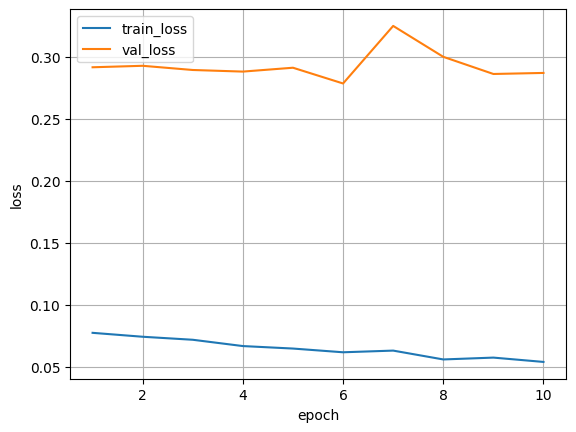

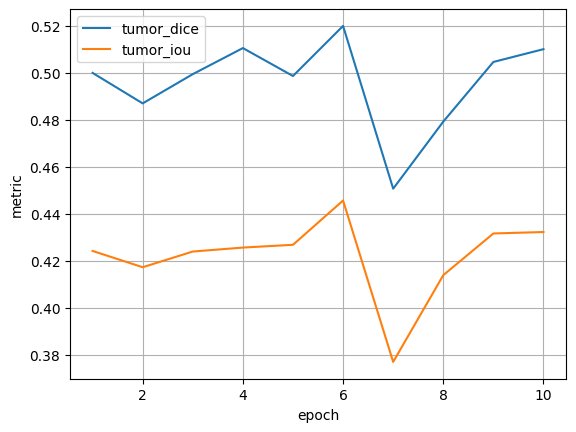

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["epoch"], df["train_loss"], label="train_loss")
plt.plot(df["epoch"], df["val_loss"], label="val_loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.grid(True)
plt.show()

plt.figure()
plt.plot(df["epoch"], df["tumor_dice"], label="tumor_dice")
plt.plot(df["epoch"], df["tumor_iou"], label="tumor_iou")
plt.xlabel("epoch"); plt.ylabel("metric"); plt.legend(); plt.grid(True)
plt.show()

## Cell 5 — Visualize predictions (sanity)

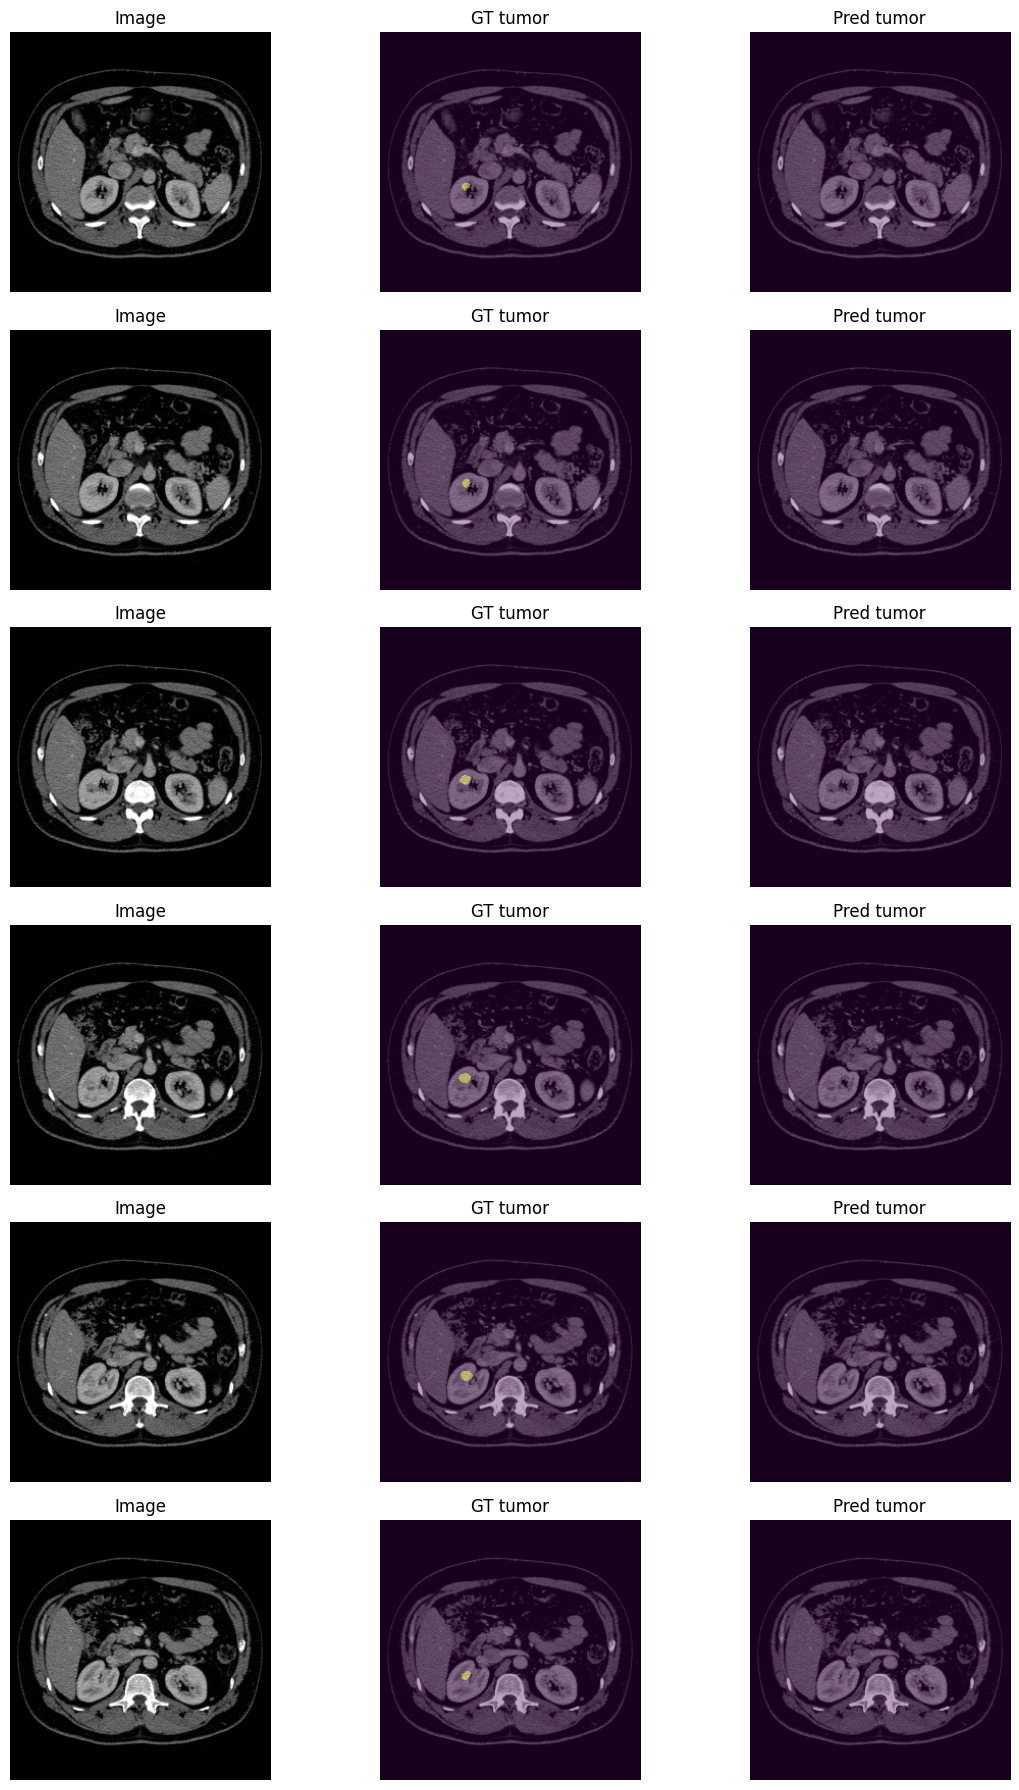

In [10]:
import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad()
def show_preds(model, loader, k=4):
    model.eval()
    xb, yb, meta = next(iter(loader))
    xb = xb.to(DEVICE)
    logits = model(xb)
    pred = torch.argmax(logits, dim=1).cpu().numpy()

    xb = xb.cpu()
    yb = yb.cpu().numpy()

    k = min(k, xb.size(0))
    plt.figure(figsize=(12, 3*k))
    for i in range(k):
        img = xb[i].mean(dim=0).numpy()
        gt_tumor = (yb[i] == 2).astype(float)
        pr_tumor = (pred[i] == 2).astype(float)

        plt.subplot(k, 3, 3*i+1)
        plt.imshow(img, cmap="gray"); plt.title("Image"); plt.axis("off")

        plt.subplot(k, 3, 3*i+2)
        plt.imshow(img, cmap="gray")
        plt.imshow(gt_tumor, alpha=0.35)
        plt.title("GT tumor"); plt.axis("off")

        plt.subplot(k, 3, 3*i+3)
        plt.imshow(img, cmap="gray")
        plt.imshow(pr_tumor, alpha=0.35)
        plt.title("Pred tumor"); plt.axis("off")

    plt.tight_layout()
    plt.show()

show_preds(model, val_loader, k=6)

## Visual sanity check on TEST predictions

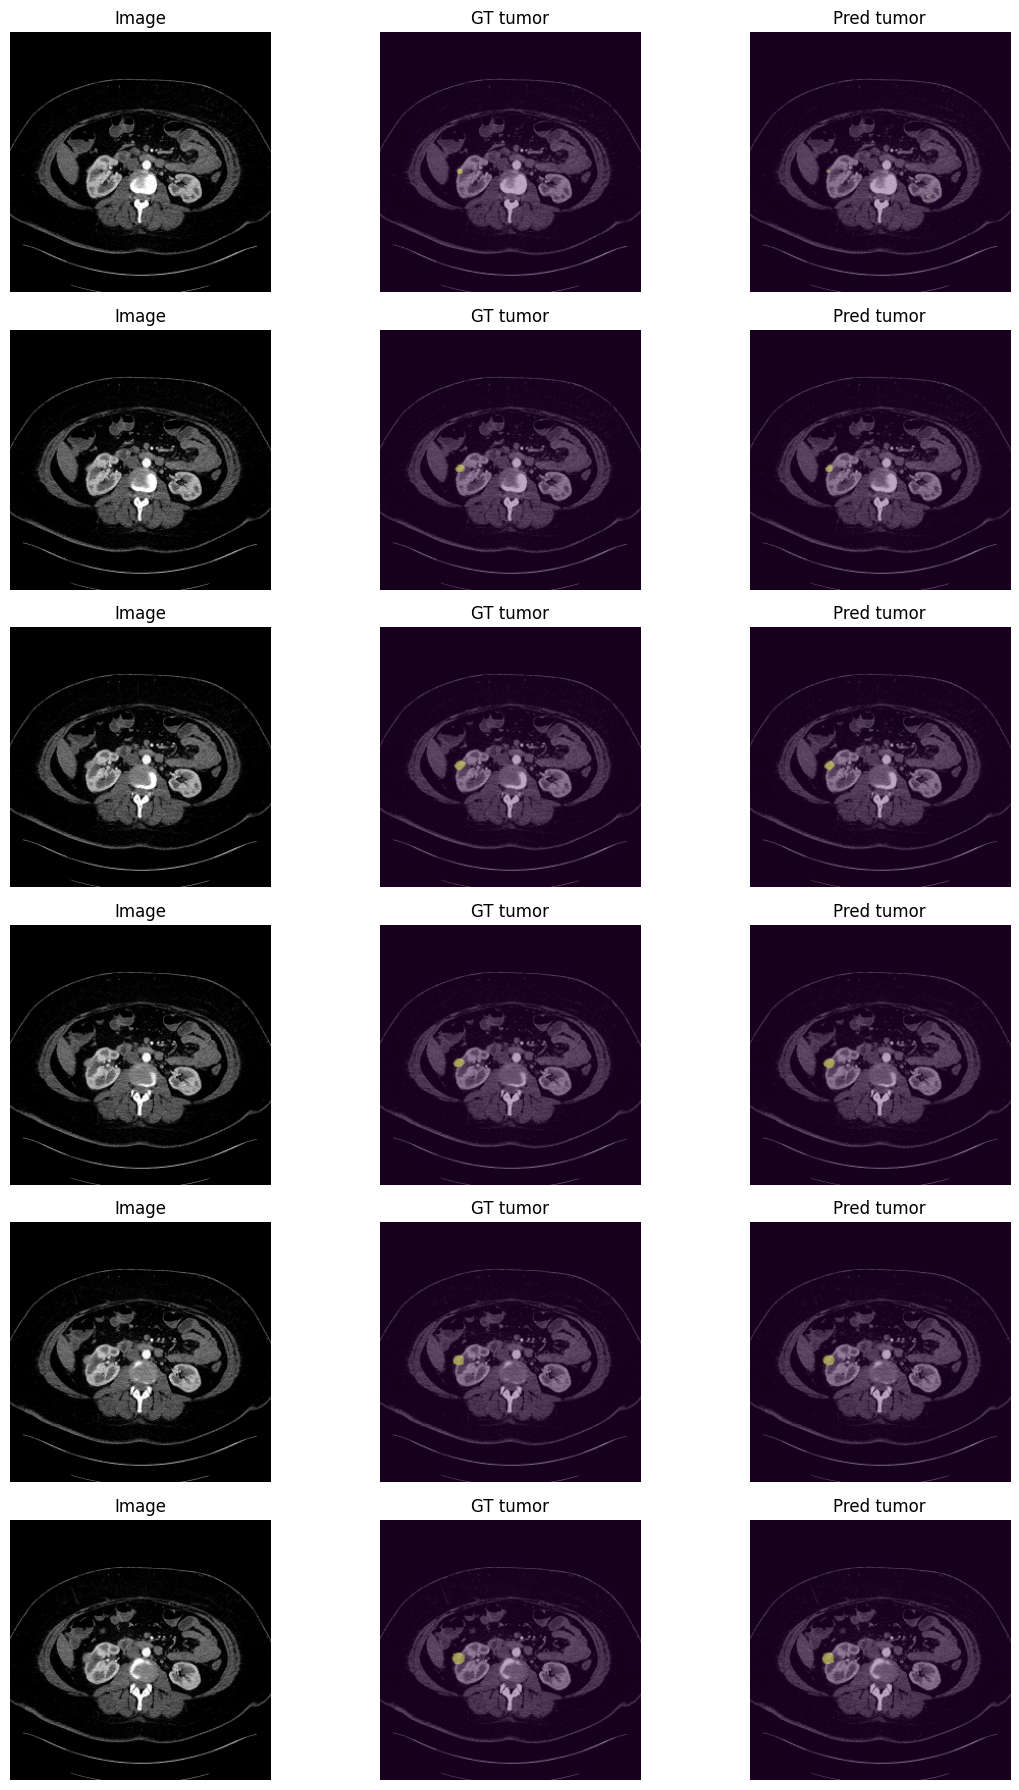

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch

@torch.no_grad()
def show_preds(model, loader, k=6):
    model.eval()
    xb, yb, meta = next(iter(loader))
    xb = xb.to(DEVICE)
    logits = model(xb)
    pred = torch.argmax(logits, dim=1).cpu().numpy()

    xb = xb.cpu()
    yb = yb.cpu().numpy()

    k = min(k, xb.size(0))
    plt.figure(figsize=(12, 3*k))
    for i in range(k):
        img = xb[i].mean(dim=0).numpy()
        gt_t = (yb[i] == 2).astype(float)
        pr_t = (pred[i] == 2).astype(float)

        plt.subplot(k, 3, 3*i+1)
        plt.imshow(img, cmap="gray"); plt.title("Image"); plt.axis("off")

        plt.subplot(k, 3, 3*i+2)
        plt.imshow(img, cmap="gray"); plt.imshow(gt_t, alpha=0.35)
        plt.title("GT tumor"); plt.axis("off")

        plt.subplot(k, 3, 3*i+3)
        plt.imshow(img, cmap="gray"); plt.imshow(pr_t, alpha=0.35)
        plt.title("Pred tumor"); plt.axis("off")

    plt.tight_layout()
    plt.show()

show_preds(model, test_loader, k=6)

In [12]:
state = torch.load(weights_path, map_location=DEVICE, weights_only=True)
model.load_state_dict(state)

NameError: name 'weights_path' is not defined